In [2]:
import bioframe as bf
import pandas as pd
import numpy as np
import bbi
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl

In [ ]:
# The same part as for the whole genome visualisation (can be simplified)

bigWig_control_consensus = bbi.open(
    'mergedReplicate/bigwig/control.mRp.clN.bigWig')
bigWig_exp_consensus = bbi.open(
    'mergedReplicate/bigwig/experimental.mRp.clN.bigWig')

In [4]:
# Get chromosome sizes
chrom_sizes = bigWig_exp_consensus.chromsizes

# Define the bin size (2000 nucleotides)
bin_size = 2000

# Create an empty list to store bin coordinates
bin_coordinates = []

# Iterate over each chromosome
for chrom, chrom_size in chrom_sizes.items():
    # Generate bin coordinates for the current chromosome
    for start in range(0, chrom_size, bin_size):
        end = min(start + bin_size, chrom_size)
        bin_coordinates.append((chrom, start, end))

# Convert the list of coordinates to a NumPy array
bin_array = np.array(bin_coordinates)

df = pd.DataFrame(bin_array, columns=['chrom', 'start', 'end'])

# Display the first few rows of the array
# print(df)

In [5]:
df = df.astype({'chrom':'string', 'start':'int', 'end':'int'})

In [ ]:
annot_gtf = pd.read_csv('Mus_musculus_GTF_genes_short_GRCm38_95.csv')

annot_gtf_tss = annot_gtf.copy()

annot_gtf_tss['start'] = annot_gtf.apply(lambda row: row['start'] if row['strand'] == '+' else row['end'], axis=1)

annot_gtf_tss['end'] = annot_gtf_tss['start']+1
bf.is_bedframe(annot_gtf_tss)

In [9]:
annot_gtf_tss['chrom'] = annot_gtf_tss['chrom'].str.replace('chr', '')

In [10]:
annot_gtf_tss = annot_gtf_tss[annot_gtf_tss['chrom'] != 'MT']

In [11]:
annot_gtf_tss.sort_values(by=['chrom', 'start'])
annot_gtf_tss = annot_gtf_tss[['chrom', 'start', 'end']]

In [12]:
# df_noSex_noTSS = bf.setdiff(df_noSex, annot_gtf_tss)

In [13]:
df_TSS = bf.coverage(df, annot_gtf_tss)
df_TSS = df_TSS[df_TSS.coverage != 0].copy()
print(len(df_TSS))

50475


In [2]:
covs = np.load("coverages_noSex_noTSS.npz")
cov_control_noSex_noTSS = covs["cov_control_noSex_noTSS"]
cov_exp_noSex_noTSS = covs["cov_exp_noSex_noTSS"]

In [3]:
covs1 = np.load("covarages_Sex.npz")
cov_control_Sex = covs1["cov_control_Sex"]
cov_exp_Sex = covs1["cov_exp_Sex"]

In [4]:
covs2 = np.load("covarages_TSS.npz")
cov_control_TSS = covs2["cov_control_TSS"]
cov_exp_TSS = covs2["cov_exp_TSS"]

In [5]:
mask1 = (cov_control_noSex_noTSS>0) & (cov_exp_noSex_noTSS>0)
xs_1 = np.log10(cov_control_noSex_noTSS[mask1])
ys_1 = np.log10(cov_exp_noSex_noTSS[mask1])

mask2 = (cov_control_Sex>0) & (cov_exp_Sex>0)
xs_2 = np.log10(cov_control_Sex[mask2])
ys_2 = np.log10(cov_exp_Sex[mask2])

mask3 = (cov_control_TSS>0) & (cov_exp_TSS>0)
xs_3 = np.log10(cov_control_TSS[mask3])
ys_3 = np.log10(cov_exp_TSS[mask3])

In [ ]:
DE_Lange_Spo11_file = pd.read_excel(r'atac_seq/ANALYSIS_3/SPO11-oligos_hotspots_NIHMS819055-supplement-9_Spo11_de_Lange.xlsx', engine='openpyxl', skiprows=8)

/users/uladzis.khauratovich/.conda/envs/night/lib/python3.8/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [4]:
DE_Lange_Spo11 = DE_Lange_Spo11_file[
    DE_Lange_Spo11_file['chr'].str.contains('chr4_JH584292_random|chrUn_GL456370|chrUn_JH584304|chrUn_GL456389|chr4_GL456216_random|chrUn_GL456392') == False
    ].reset_index(drop=True)

In [5]:
DE_Lange_Spo11_cov_sorted = DE_Lange_Spo11.sort_values(by=["Hits"], ascending=False).reset_index(drop=True).copy()


In [7]:
DE_Lange_Spo11_cov_sorted_2kb = (
    DE_Lange_Spo11_cov_sorted
        .assign(
            str_win2=lambda x: x['center'] - 1000,
            end_win2=lambda x: x['center'] + 1000,
        )
)

In [12]:
print(len(DE_Lange_Spo11_cov_sorted))

13945


In [10]:
DE_Lange_Spo11_cov_sorted_hottest = DE_Lange_Spo11_cov_sorted_2kb.iloc[:1394]

In [28]:
Spo11_hottest_hotspots = DE_Lange_Spo11_cov_sorted_hottest[['chr', 'str_win2', 'end_win2']]
Spo11_hottest_hotspots.columns =['chrom', 'start', 'end']
print(len(Spo11_hottest_hotspots))

1394


In [29]:
Spo11_all_hotspots = DE_Lange_Spo11_cov_sorted_2kb[['chr', 'str_win2', 'end_win2']]
Spo11_all_hotspots.columns =['chrom', 'start', 'end']

In [30]:
Spo11_all_hotspots['chrom'] = Spo11_all_hotspots['chrom'].str.replace(r'chr', '', regex=True)

/tmp/ipykernel_74852/2144858834.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spo11_all_hotspots['chrom'] = Spo11_all_hotspots['chrom'].str.replace(r'chr', '', regex=True)


In [31]:
Spo11_hottest_hotspots['chrom'] = Spo11_hottest_hotspots['chrom'].str.replace(r'chr', '', regex=True)

/tmp/ipykernel_74852/2590035490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spo11_hottest_hotspots['chrom'] = Spo11_hottest_hotspots['chrom'].str.replace(r'chr', '', regex=True)


In [32]:
df0 = Spo11_all_hotspots

cov_control_DSB = bigWig_control_consensus.stackup(df0["chrom"],
                                                          df0["start"],
                                                          df0["end"],
                                                          bins=1, summary='sum').flatten()
cov_exp_DSB = bigWig_exp_consensus.stackup(df0["chrom"],
                                                   df0["start"],
                                                   df0["end"],
                                                   bins=1, summary='sum').flatten()

In [32]:
df0 = Spo11_hottest_hotspots

cov_control_hDSB = bigWig_control_consensus.stackup(df0["chrom"],
                                                          df0["start"],
                                                          df0["end"],
                                                          bins=1, summary='sum').flatten()
cov_exp_hDSB = bigWig_exp_consensus.stackup(df0["chrom"],
                                                   df0["start"],
                                                   df0["end"],
                                                   bins=1, summary='sum').flatten()

In [33]:
mask4 = (cov_control_DSB>0) & (cov_exp_DSB>0)
xs_4 = np.log10(cov_control_DSB[mask4])
ys_4 = np.log10(cov_exp_DSB[mask4])

NameError: name 'cov_control_DSB' is not defined

In [34]:
mask5 = (cov_control_hDSB>0) & (cov_exp_hDSB>0)
xs_5 = np.log10(cov_control_hDSB[mask5])
ys_5 = np.log10(cov_exp_hDSB[mask5])

In [35]:
mask1 = (cov_control_noSex_noTSS>0) & (cov_exp_noSex_noTSS>0)
xs_1 = np.log10(cov_control_noSex_noTSS[mask1])
ys_1 = np.log10(cov_exp_noSex_noTSS[mask1])

mask2 = (cov_control_Sex>0) & (cov_exp_Sex>0)
xs_2 = np.log10(cov_control_Sex[mask2])
ys_2 = np.log10(cov_exp_Sex[mask2])

mask3 = (cov_control_TSS>0) & (cov_exp_TSS>0)
xs_3 = np.log10(cov_control_TSS[mask3])
ys_3 = np.log10(cov_exp_TSS[mask3])

In [36]:
cs_1 = np.full(len(xs_1), '#BDBDBD') #all blue -> grey
cs_2 = np.full(len(xs_2), '#BDBDBD') #Sex green -> grey
cs_3 = np.full(len(xs_3), '#BDBDBD') #TSS red -> grey
cs_4 = np.full(len(xs_4), 'black') #all DSBs

NameError: name 'xs_4' is not defined

In [37]:
al_1 = np.full(len(xs_1), 0.03)
al_2 = np.full(len(xs_2), 0.03)
al_3 = np.full(len(xs_3), 0.03)
al_4 = np.full(len(xs_4), 0.5)

NameError: name 'xs_4' is not defined

In [38]:
xs = np.concatenate([xs_1, xs_2, xs_3, xs_4])
ys = np.concatenate([ys_1, ys_2, ys_3, ys_4])
cs = np.concatenate([cs_1, cs_2, cs_3, cs_4])
al = np.concatenate([al_1, al_2, al_3, al_4])

NameError: name 'xs_4' is not defined

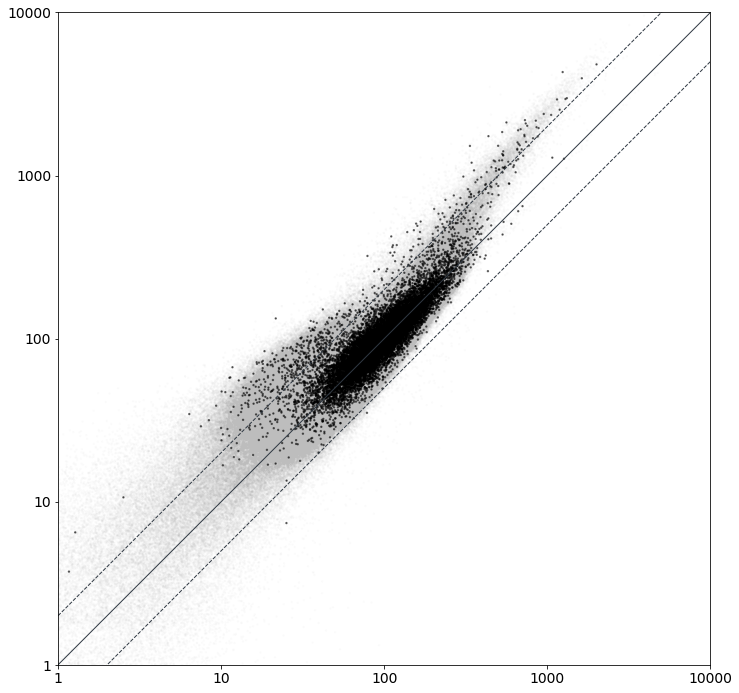

In [ ]:
# Bins centered at DSB hotspots (all 13945)

plt.figure(figsize=[15,12])

plt.scatter(
    xs,
    ys,
    c=cs,
    s=2,
    alpha=al,
    rasterized=True,   
    zorder=0           
)

plt.gca().set(
    aspect=1.0,
    xlim=[0, 4],
    ylim=[0, 4]
)

plt.tick_params(labelsize=14)

def custom_tick_formatter(x, pos):
    return f'{int(10**x)}'  # Round and convert to integer

# Custom tick locator
def custom_tick_locator():
    locs = np.arange(0, 4.1, 1)  # Adjust these values based on your data
    return plt.FixedLocator(locs)

# Set x-axis tick labels to non-log-transformed values
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().xaxis.set_major_locator(custom_tick_locator())

# Set y-axis tick labels to non-log-transformed values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().yaxis.set_major_locator(custom_tick_locator())

# Add diagonal lines
x_line = np.linspace(0, 4, 100)
y_line_plus = x_line + np.log10(2) #log10(2) = 0.301, log10(1.5) = 0.176
y_line_minus = x_line - np.log10(2)
y_line_equals_x = x_line

plt.plot(x_line, y_line_plus, color='#303943', linestyle='dashed', linewidth=1)
plt.plot(x_line, y_line_equals_x, color='#303943', linestyle='solid', linewidth=1)
plt.plot(x_line, y_line_minus, color='#303943', linestyle='dashed', linewidth=1)

# plt.savefig("chromatin_accessibility_all_DSBs.svg", dpi=300)


In [39]:
al_1 = np.full(len(xs_1), 0.02)
al_2 = np.full(len(xs_2), 0.02)
al_3 = np.full(len(xs_3), 0.02)


In [ ]:
cs_1 = np.full(len(xs_1), '#BDBDBD') #all blue -> grey
cs_2 = np.full(len(xs_2), '#BDBDBD') #Sex green -> grey
cs_3 = np.full(len(xs_3), '#BDBDBD') #TSS red -> grey


In [50]:
cs_5 = np.full(len(xs_5), '#ce3f0c') #hottest DSBs
al_5 = np.full(len(xs_5), 0.8)

In [51]:
xsh = np.concatenate([xs_1, xs_2, xs_3, xs_5])
ysh = np.concatenate([ys_1, ys_2, ys_3, ys_5])
csh = np.concatenate([cs_1, cs_2, cs_3, cs_5])
alh = np.concatenate([al_1, al_2, al_3, al_5])

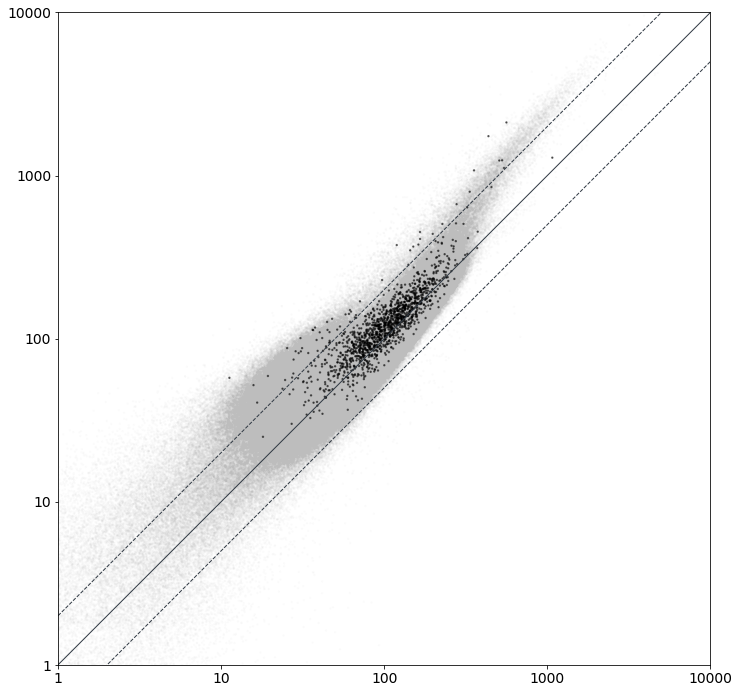

In [46]:
# Bins centered at the 10% hottest DSB hotspots (1394)

plt.figure(figsize=[15,12])

plt.scatter(
    xsh,
    ysh,
    c=csh,
    s=2,
    alpha=alh,
    rasterized=True,     # <- this embeds the dots as a bitmap
    zorder=0             # keep it “under” the vector lines
)

plt.gca().set(
    aspect=1.0,
    xlim=[0, 4],
    ylim=[0, 4]
)

plt.tick_params(labelsize=14)

def custom_tick_formatter(x, pos):
    return f'{int(10**x)}'  # Round and convert to integer

# Custom tick locator
def custom_tick_locator():
    locs = np.arange(0, 4.1, 1)  # Adjust these values based on your data
    return plt.FixedLocator(locs)

# Set x-axis tick labels to non-log-transformed values
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().xaxis.set_major_locator(custom_tick_locator())

# Set y-axis tick labels to non-log-transformed values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().yaxis.set_major_locator(custom_tick_locator())

# Add diagonal lines
x_line = np.linspace(0, 4, 100)
y_line_plus = x_line + np.log10(2) #log10(2) = 0.301, log10(1.5) = 0.176
y_line_minus = x_line - np.log10(2)
y_line_equals_x = x_line

plt.plot(x_line, y_line_plus, color='#303943', linestyle='dashed', linewidth=1)
plt.plot(x_line, y_line_equals_x, color='#303943', linestyle='solid', linewidth=1)
plt.plot(x_line, y_line_minus, color='#303943', linestyle='dashed', linewidth=1)

# plt.savefig("chromatin_accessibility_all_hottest_DSBs.svg", dpi=300)


In [ ]:
mpl.rcParams['pdf.fonttype'] = 42  
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 20 


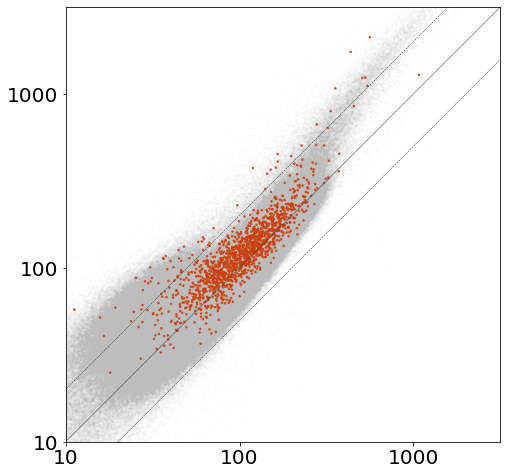

In [ ]:
# Bins centered at the 10% hottest DSB hotspots (1394) [zoomed in version]

plt.figure(figsize=[8,8])

plt.scatter(
    xsh,
    ysh,
    c=csh,
    s=2.5,
    alpha=alh,
    rasterized=True,     
    zorder=0            
)

plt.gca().set(
    aspect=1.0,
    xlim=[1, 3.5],
    ylim=[1, 3.5]
)

# plt.xlabel('Chromatin accesibility in 2kb genomic bins, CONTROL', fontsize=16)
# plt.ylabel('Chromatin accesibility in 2kb genomic bins, CHD1 KO', fontsize=16)

plt.tick_params(axis='both', labelsize=20)

def custom_tick_formatter(x, pos):
    return f'{int(10**x)}'  # Round and convert to integer

# Custom tick locator
def custom_tick_locator():
    locs = np.arange(0, 4.1, 1)  # Adjust these values based on your data
    return plt.FixedLocator(locs)

# Set x-axis tick labels to non-log-transformed values
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().xaxis.set_major_locator(custom_tick_locator())

# Set y-axis tick labels to non-log-transformed values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().yaxis.set_major_locator(custom_tick_locator())

# Add diagonal lines
x_line = np.linspace(0, 4, 100)
y_line_plus = x_line + np.log10(2) #log10(2) = 0.301, log10(1.5) = 0.176
y_line_minus = x_line - np.log10(2)
y_line_equals_x = x_line

plt.plot(x_line, y_line_plus, color='#303943', linestyle='dashed', linewidth=0.5)
plt.plot(x_line, y_line_equals_x, color='#303943', linestyle='solid', linewidth=0.5)
plt.plot(x_line, y_line_minus, color='#303943', linestyle='dashed', linewidth=0.5)

# plt.savefig(
#     "Scatterplot_all_hottest_DSBs_zoomed_in_orange_c3.pdf",
#     dpi=300,                                                 
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False                                       
# )